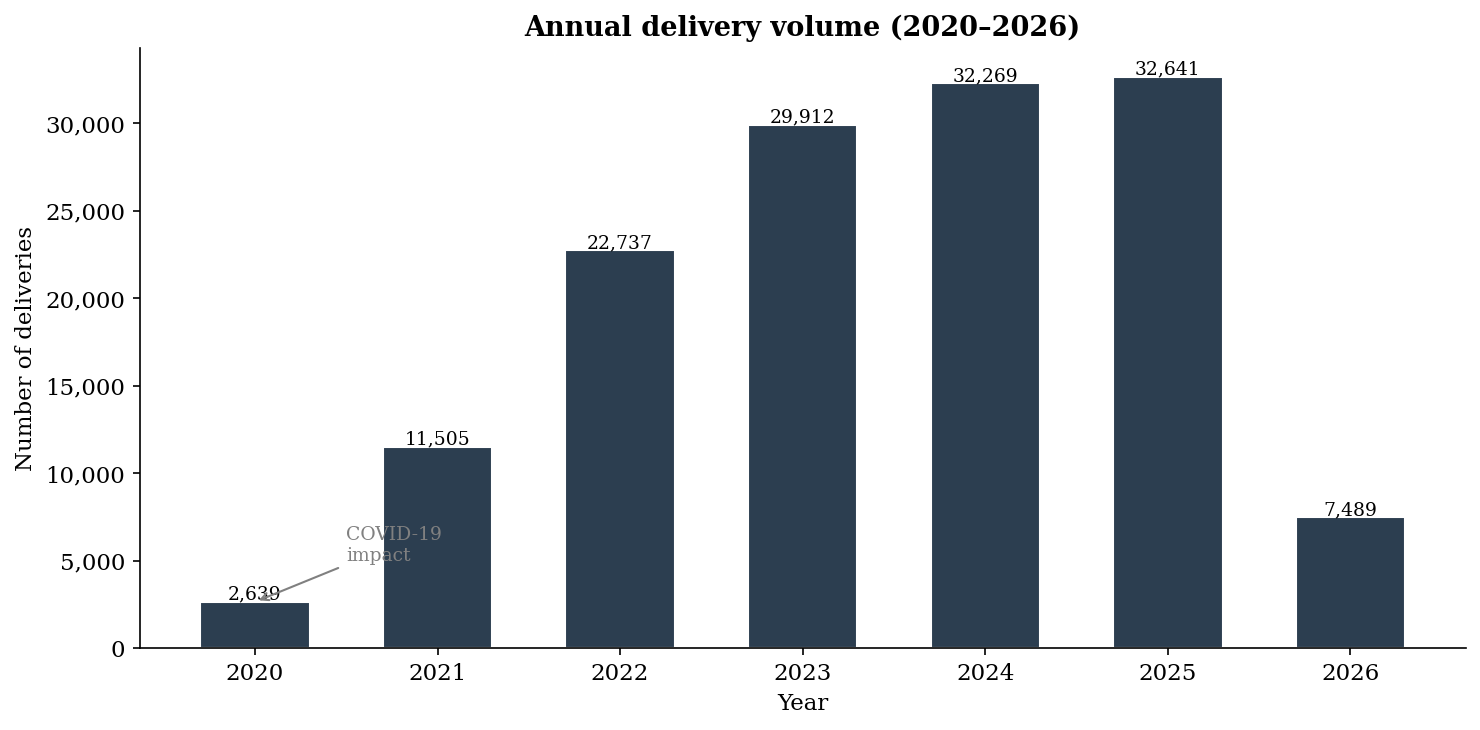

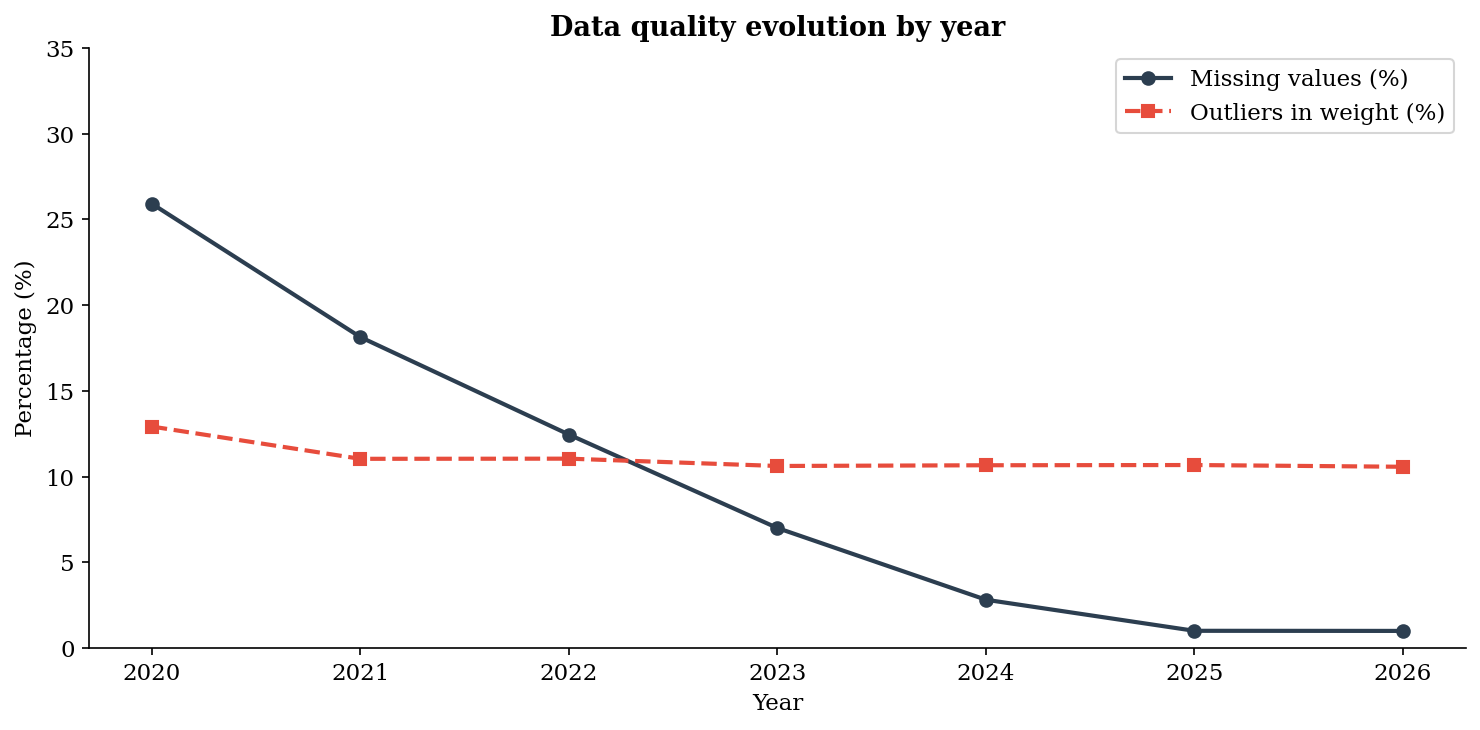

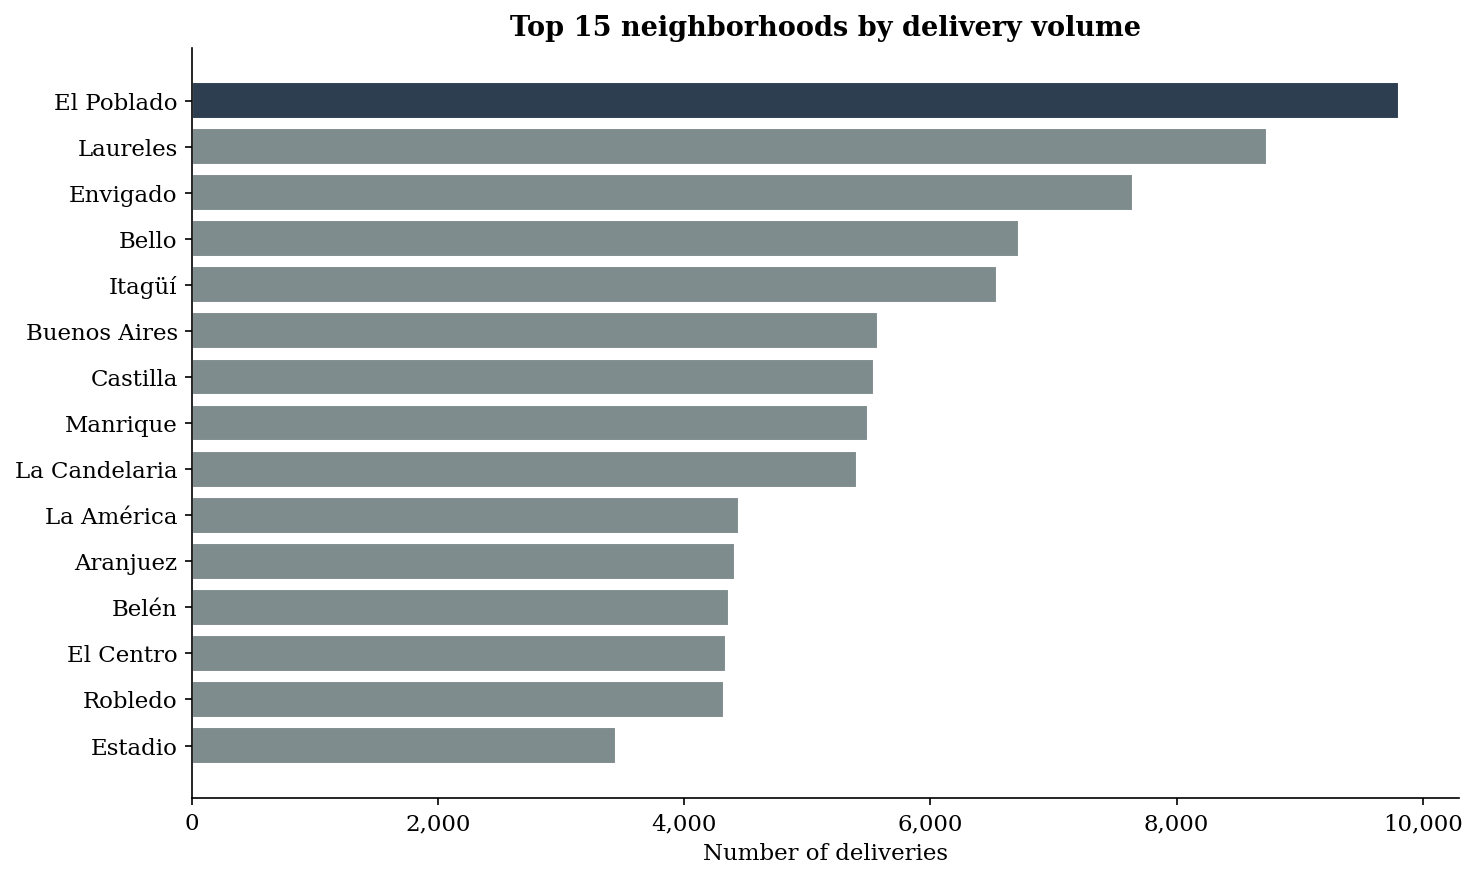

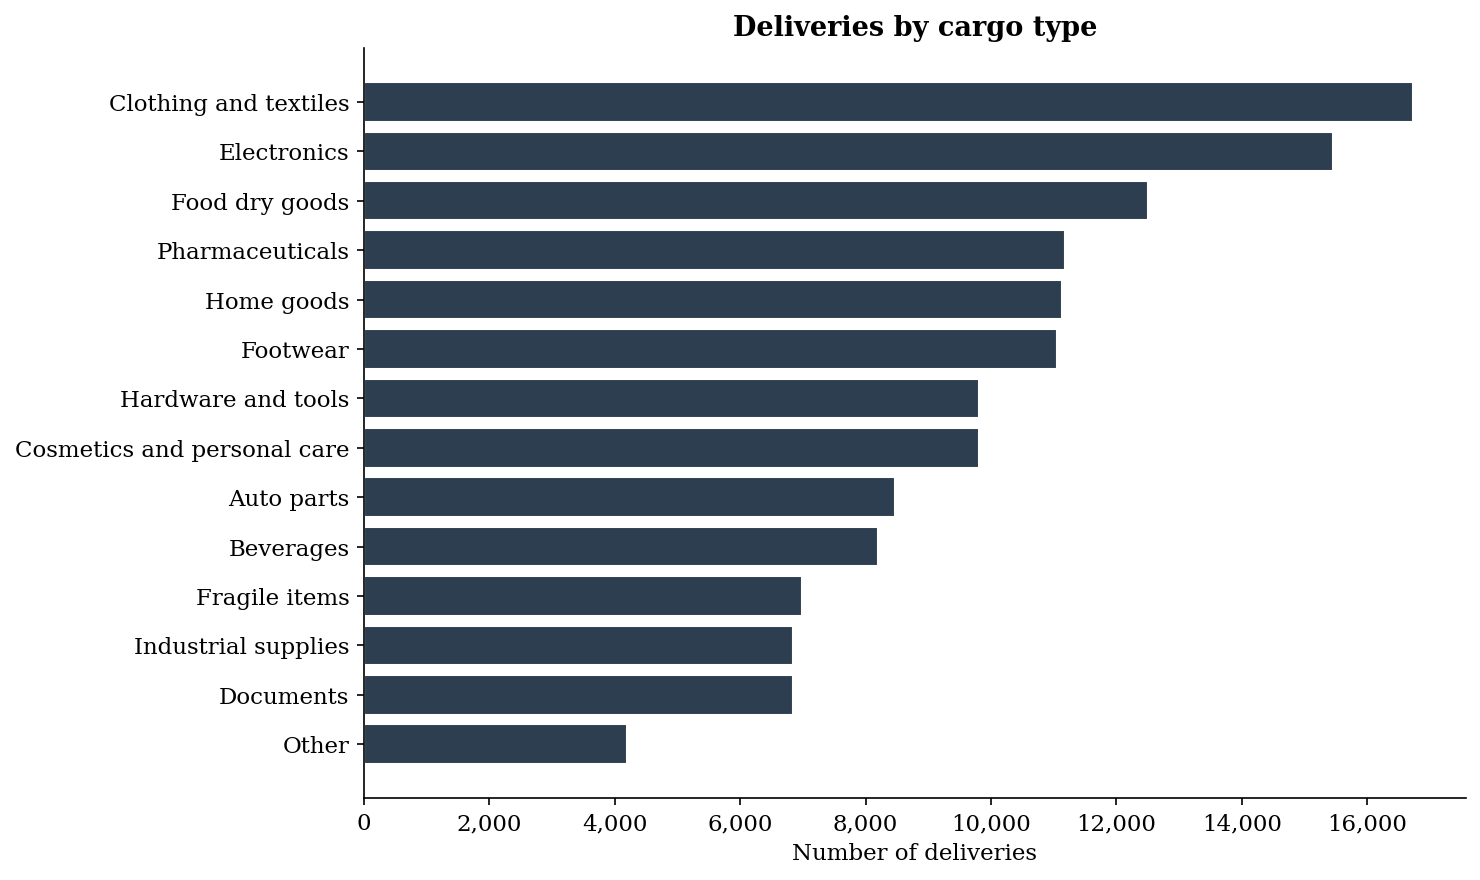

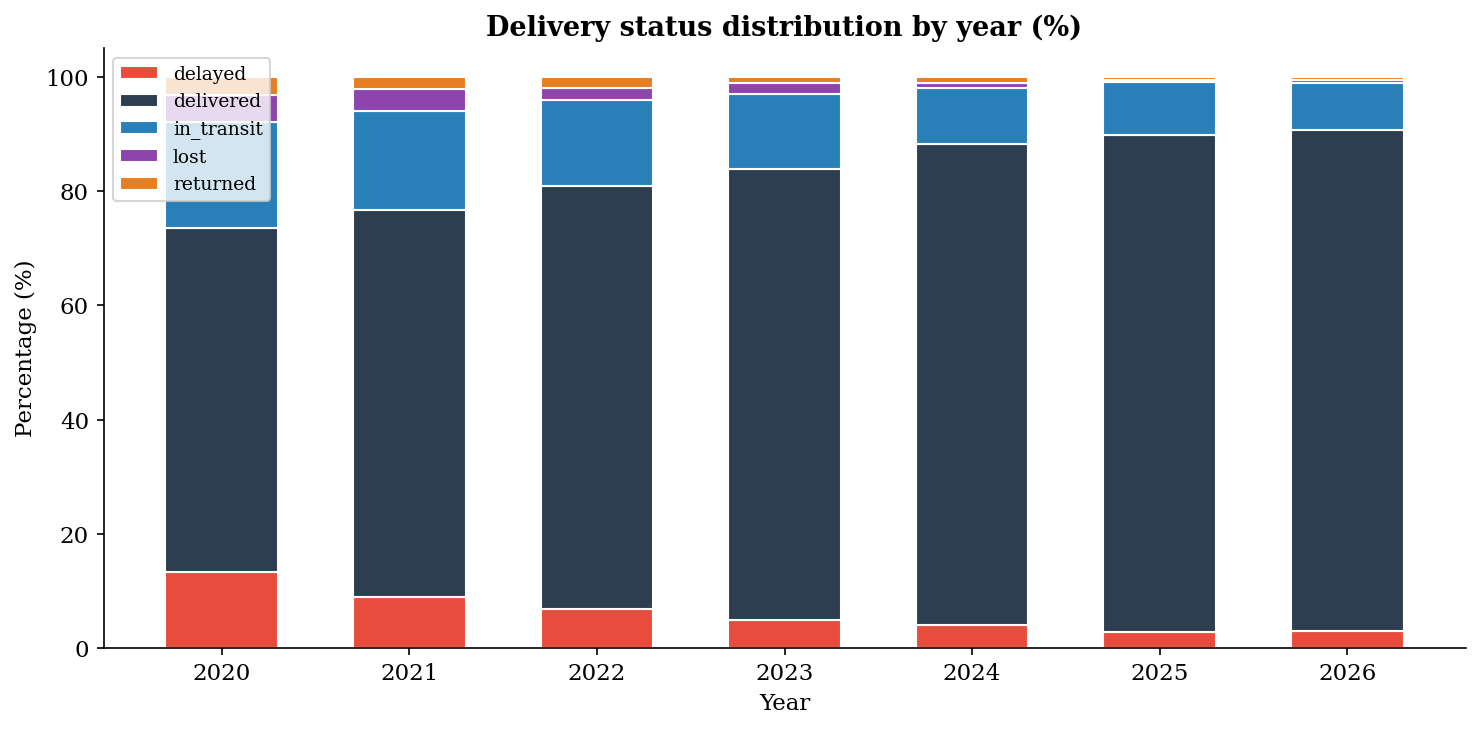

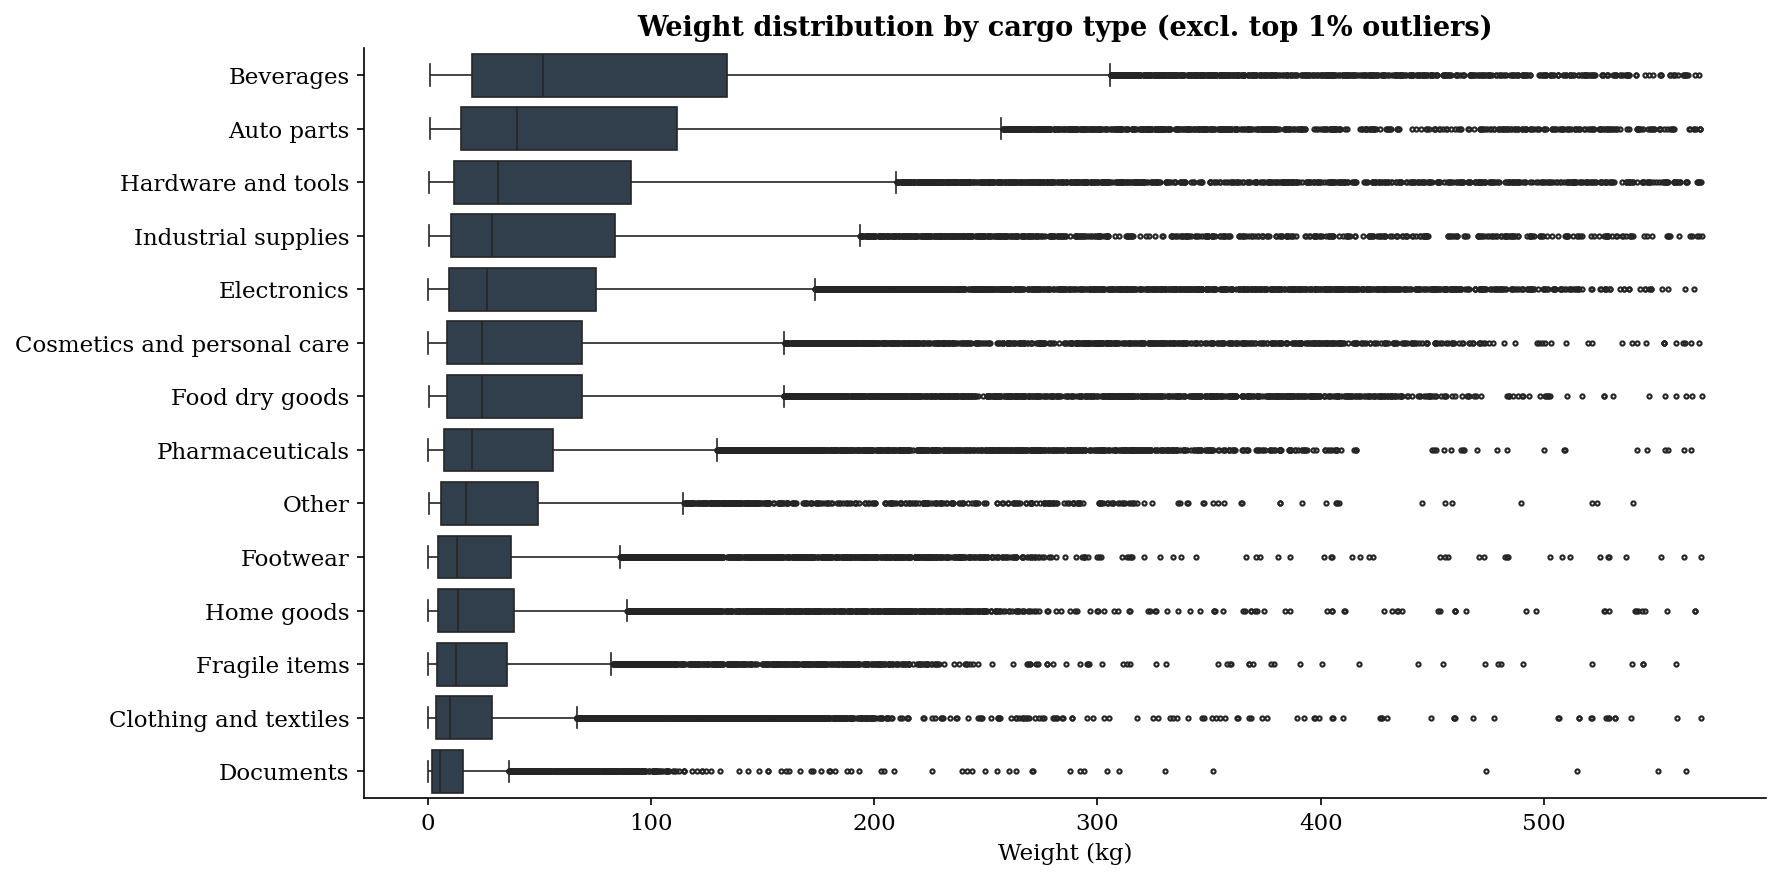

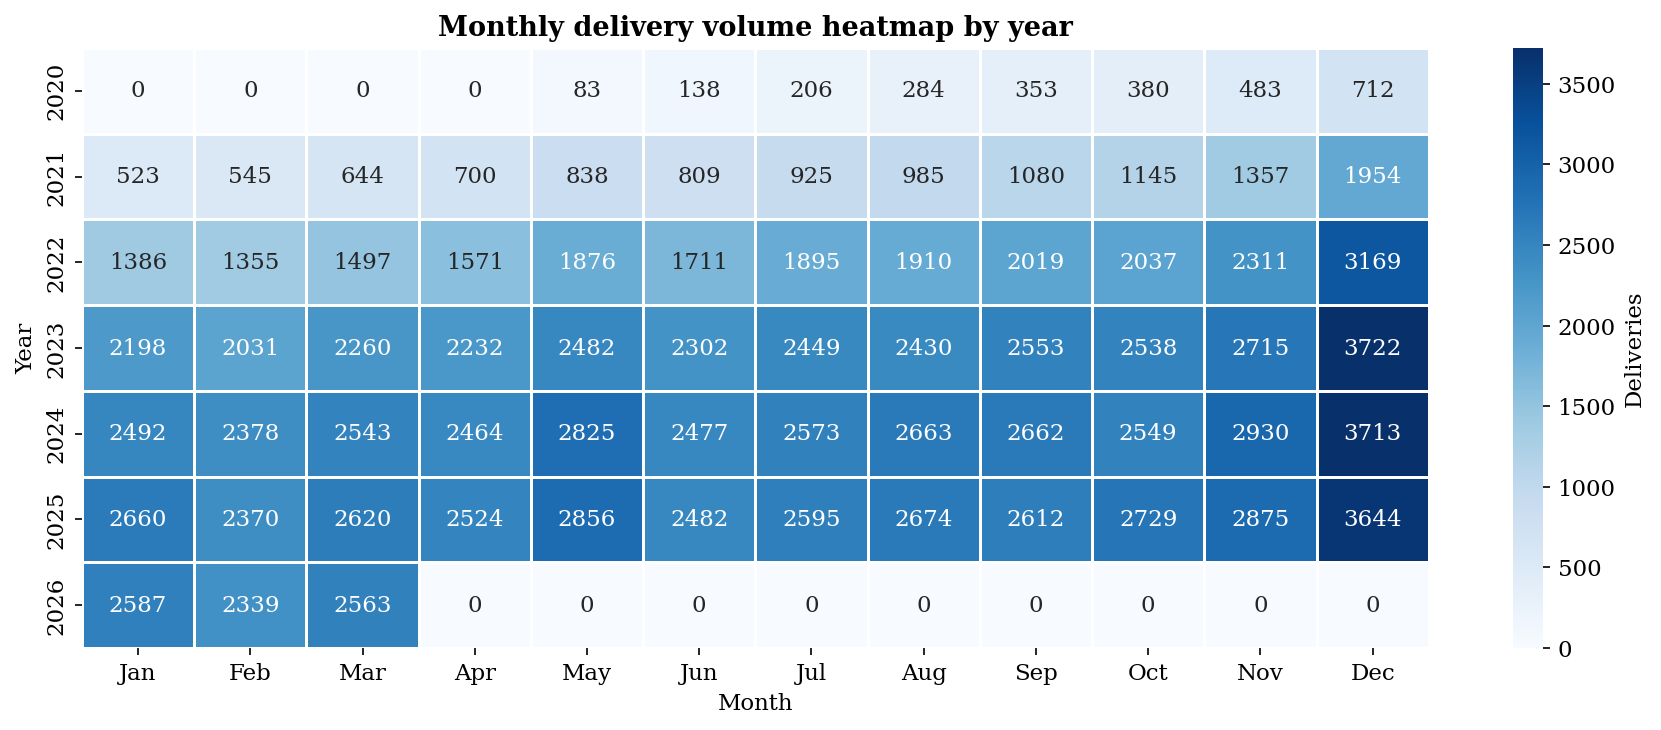

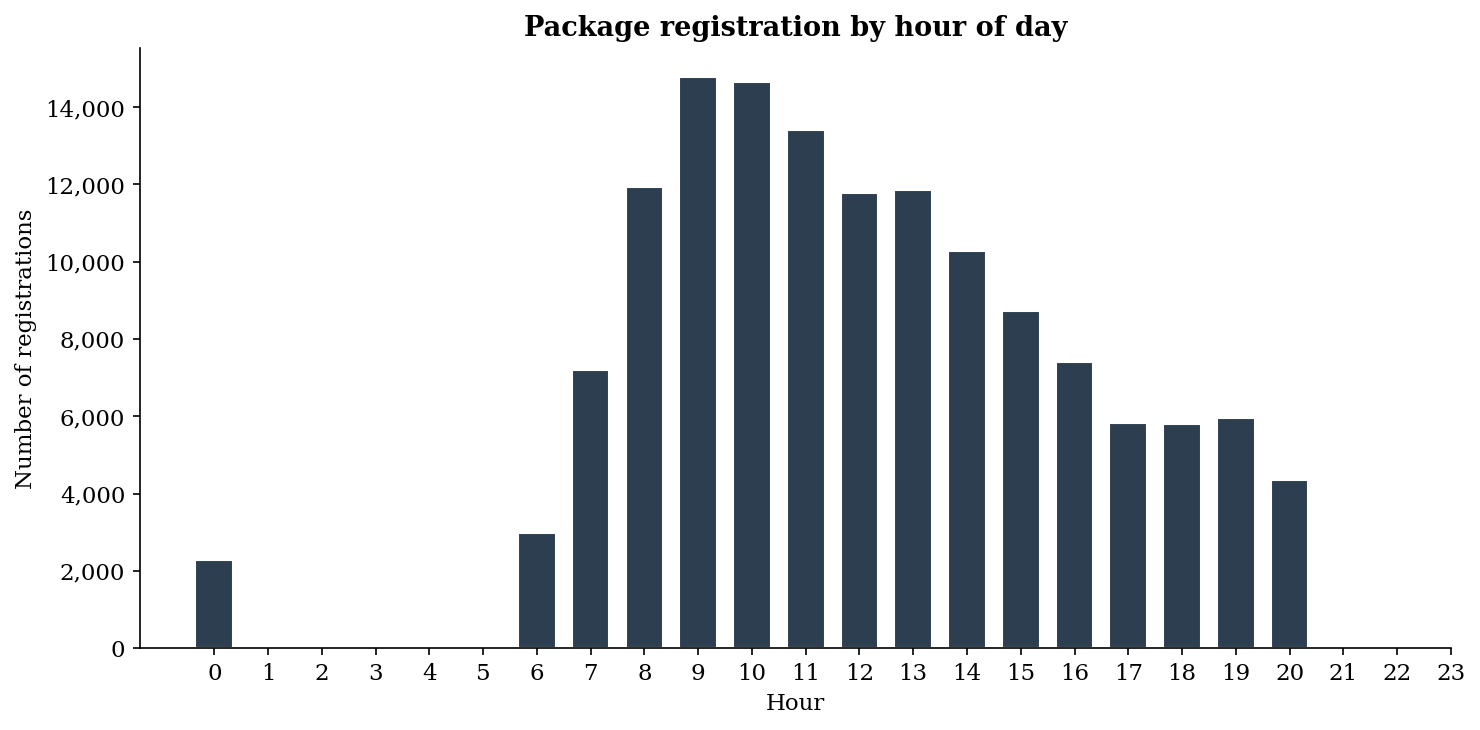

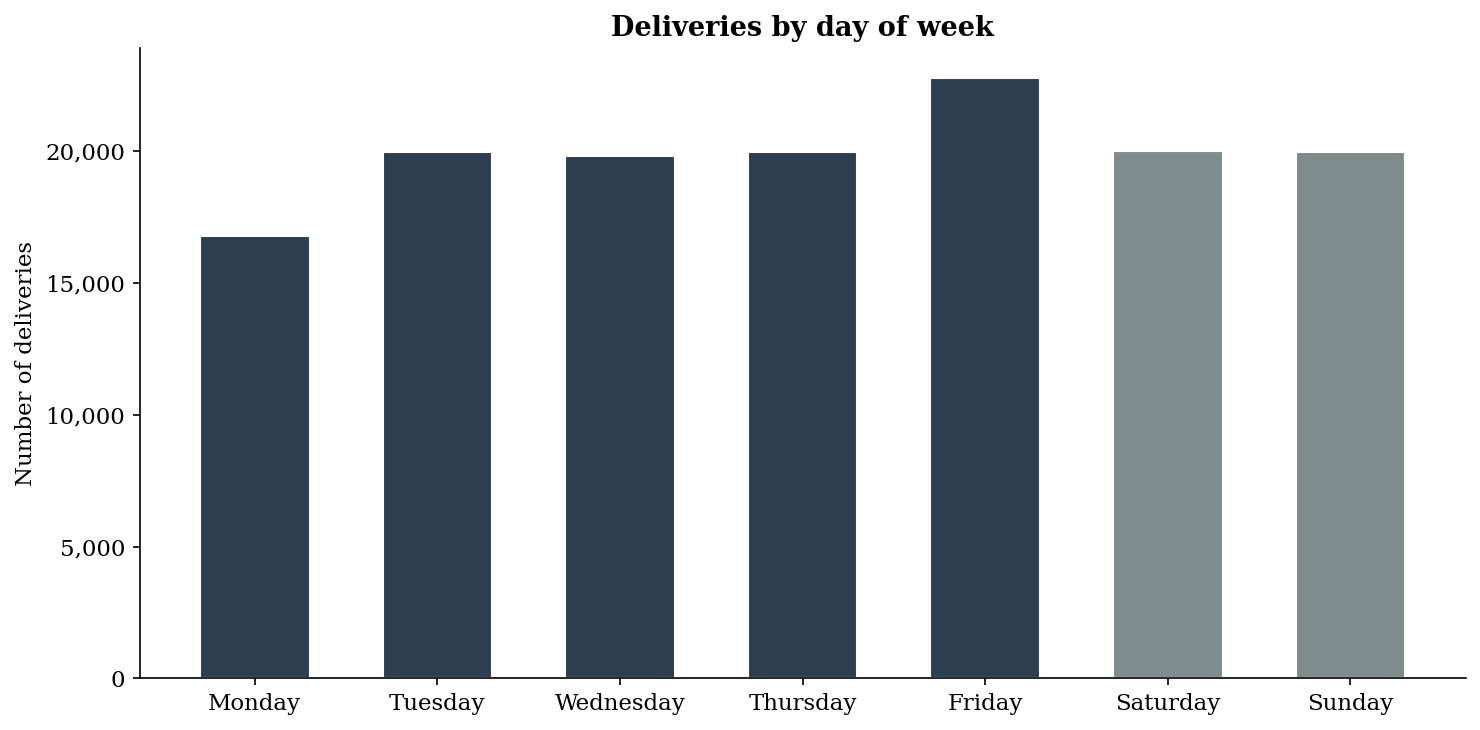

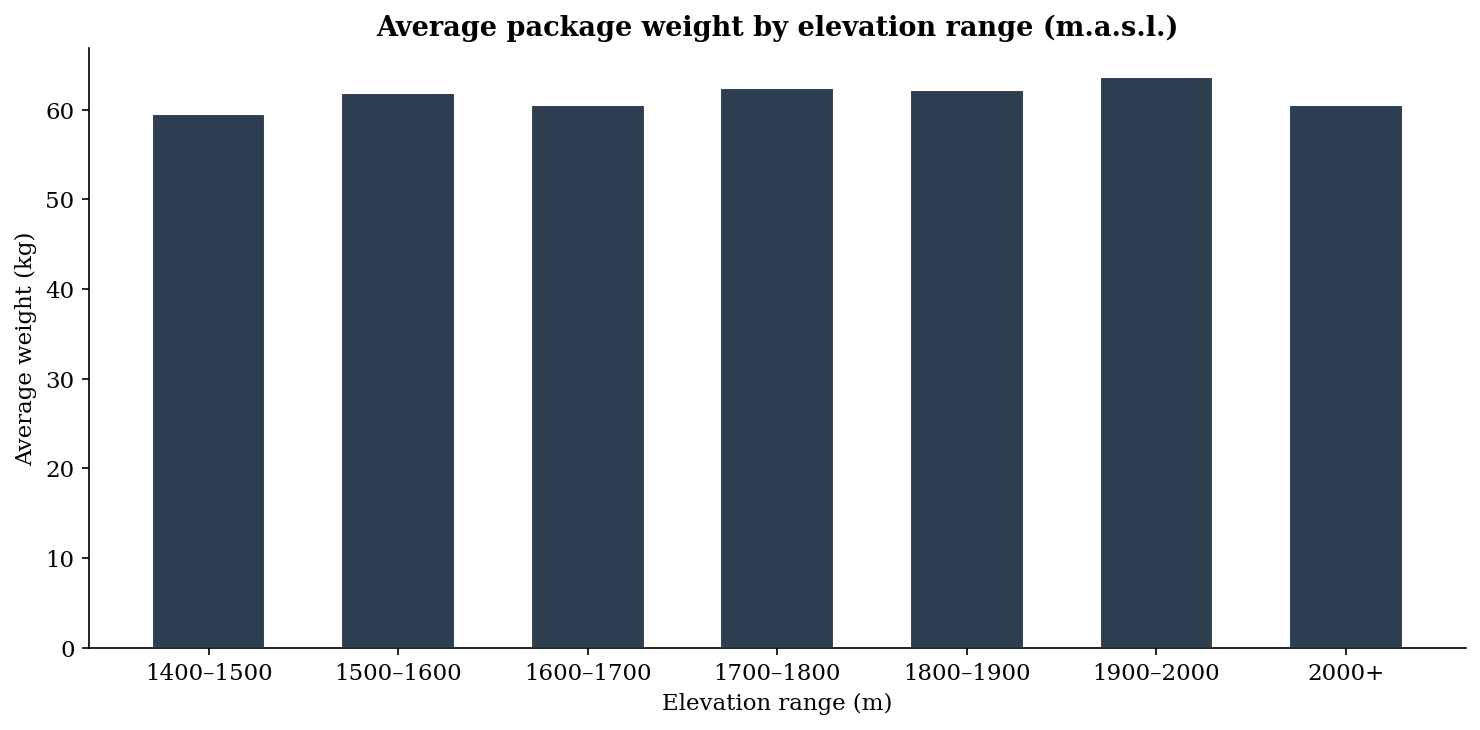


✅ All 10 figures saved.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Config global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

DARK = '#2C3E50'
MID  = '#7F8C8D'
RED  = '#E74C3C'
BLUE = '#2980B9'

df = pd.read_csv(r'C:\Users\Santiago\Videos\TrabajoGrado-main\dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['year']      = df['timestamp'].dt.year
df['month']     = df['timestamp'].dt.month
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['date']      = df['timestamp'].dt.date
df['elev_bin']  = pd.cut(df['elevation_m'],
    bins=[1400,1500,1600,1700,1800,1900,2000,2600],
    labels=['1400–1500','1500–1600','1600–1700','1700–1800','1800–1900','1900–2000','2000+'])

# ══════════════════════════════════════════════════════════════════════════
# FIG 1 — Volumen anual
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
yearly = df.groupby('year').size()
bars = ax.bar(yearly.index, yearly.values, color=DARK, width=0.6, edgecolor='white')
ax.set_title('Annual delivery volume (2020–2026)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}', ha='center', fontsize=9)
ax.annotate('COVID-19\nimpact', xy=(2020, yearly[2020]),
            xytext=(2020.5, 5000),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig1_annual_volume.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 2 — Calidad de datos por año
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
missing = df.groupby('year')['neighborhood'].apply(lambda x: x.isnull().mean()*100)
outlier = df.groupby('year')['weight_kg'].apply(lambda g: (
    (g < g.quantile(0.25) - 1.5*(g.quantile(0.75)-g.quantile(0.25))) |
    (g > g.quantile(0.75) + 1.5*(g.quantile(0.75)-g.quantile(0.25)))
).mean()*100)
ax.plot(missing.index, missing.values, marker='o', color=DARK, linewidth=2, label='Missing values (%)')
ax.plot(outlier.index, outlier.values, marker='s', color=RED, linewidth=2,
        linestyle='--', label='Outliers in weight (%)')
ax.set_title('Data quality evolution by year')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend()
ax.set_ylim(0, 35)
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig2_data_quality.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 3 — Top 15 barrios
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
top_n = df['neighborhood'].value_counts().dropna().head(15)
colors = [DARK if i == 0 else MID for i in range(len(top_n))]
ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 15 neighborhoods by delivery volume')
ax.set_xlabel('Number of deliveries')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig3_neighborhoods.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 4 — Tipos de carga
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
cargo = df['cargo_type'].value_counts()
ax.barh(cargo.index[::-1], cargo.values[::-1], color=DARK, edgecolor='white')
ax.set_title('Deliveries by cargo type')
ax.set_xlabel('Number of deliveries')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig4_cargo_type.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 5 — Estados de entrega por año
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
status_year = df.groupby(['year','status']).size().unstack(fill_value=0)
status_pct  = status_year.div(status_year.sum(axis=1), axis=0) * 100
status_colors = {'delivered': DARK, 'in_transit': BLUE, 'delayed': RED,
                 'returned': '#E67E22', 'lost': '#8E44AD'}
bottom = np.zeros(len(status_pct))
for col in status_pct.columns:
    ax.bar(status_pct.index, status_pct[col], bottom=bottom,
           label=col, color=status_colors.get(col, MID), edgecolor='white', width=0.6)
    bottom += status_pct[col].values
ax.set_title('Delivery status distribution by year (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig5_status_year.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 6 — Distribución de peso por tipo de carga
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
order = df.groupby('cargo_type')['weight_kg'].median().sort_values(ascending=False).index
df_filtered = df[df['weight_kg'] < df['weight_kg'].quantile(0.99)]
sns.boxplot(data=df_filtered, y='cargo_type', x='weight_kg', order=order,
            color=DARK, ax=ax, linewidth=0.8, fliersize=2)
ax.set_title('Weight distribution by cargo type (excl. top 1% outliers)')
ax.set_xlabel('Weight (kg)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig6_weight_cargo.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 7 — Heatmap volumen mensual por año
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df.groupby(['year','month']).size().unstack(fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(pivot, ax=ax, cmap='Blues', fmt='d', annot=True,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Deliveries'})
ax.set_title('Monthly delivery volume heatmap by year')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig7_heatmap.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 8 — Registros por hora del día
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
hourly = df.groupby('hour').size()
ax.bar(hourly.index, hourly.values, color=DARK, edgecolor='white', width=0.7)
ax.set_title('Package registration by hour of day')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of registrations')
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig8_hourly.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 9 — Entregas por día de la semana
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('dayofweek').size()
colors_dow = [DARK if i < 5 else MID for i in range(7)]
ax.bar(dias, dow.values, color=colors_dow, edgecolor='white', width=0.6)
ax.set_title('Deliveries by day of week')
ax.set_xlabel('')
ax.set_ylabel('Number of deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig9_dayofweek.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# FIG 10 — Elevación vs peso promedio
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
elev_weight = df.groupby('elev_bin', observed=True)['weight_kg'].mean()
ax.bar(elev_weight.index, elev_weight.values, color=DARK, edgecolor='white', width=0.6)
ax.set_title('Average package weight by elevation range (m.a.s.l.)')
ax.set_xlabel('Elevation range (m)')
ax.set_ylabel('Average weight (kg)')
plt.tight_layout()
plt.savefig(r'C:\Users\Santiago\Videos\TrabajoGrado-main\fig10_elev_weight.png', bbox_inches='tight')
plt.show()

print("\n✅ All 10 figures saved.")